# Introduction to Next Word Predictor



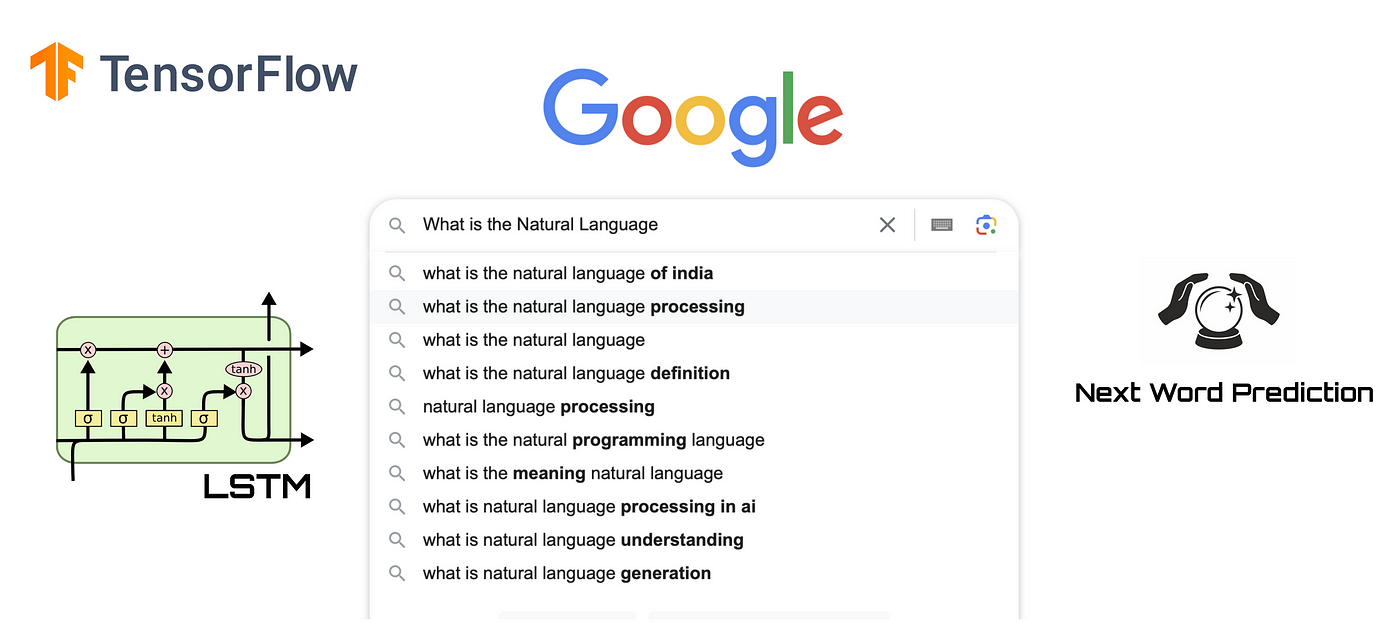



The Next Word Predictor is a machine learning model designed to predict the next word in a sequence of text. This model utilizes advanced neural network architectures, specifically Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU) networks, to understand the context of the input text and generate coherent and contextually relevant predictions.



In this notebook, we will explore the process of building a next word predictor using a dataset of jokes. The model will be trained on sequences of words, allowing it to learn patterns and relationships between words. After training, the model will be able to generate the next word based on a given input text, making it a useful tool for applications such as chatbots, text completion, and creative writing assistance.



---

### 📌 Importing the necessary libraries


In [2]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, GRU
from tensorflow.keras.layers import Bidirectional

### 📌 Loading the dataset
We will utilize the jokes dataset to train our model.

In [3]:
data = pd.read_csv('/kaggle/input/jester-17m-jokes-ratings-dataset/jester_items.csv')
data.head()

,jokeId,jokeText
0,1,"A man visits the doctor. The doctor says ""I ha..."
1,2,This couple had an excellent relationship goin...
2,3,Q. What's 200 feet long and has 4 teeth? \n\nA...
3,4,Q. What's the difference between a man and a t...
4,5,Q.\tWhat's O. J. Simpson's Internet address? \...


---

# **Data Preprocessing**

In [4]:
input_data = ''.join(data['jokeText'])

### 📌 Tokenizing the data
Tokenization is the process of converting raw text into individual units, or tokens, which can be words, phrases, or symbols. This step is crucial in natural language processing as it allows the model to understand and manipulate text data effectively. By breaking down the text into manageable pieces, we can prepare it for further analysis, such as training a predictive model or performing sentiment analysis.

In [5]:
tokenizer = Tokenizer(lower = True, oov_token = "undefined")
tokenizer.fit_on_texts([input_data]) # If You cannout pass through list then it will encode the input letter by letter insted word by word

In [6]:
max(tokenizer.word_index.values())

2298

### 📌 Titles text into sequences and make n_gram model

This section converts the jokes into sequences of integers using the tokenizer. Each joke is tokenized into a sequence of numbers, where each number corresponds to a unique word. `The structured_data list is populated with sequences of increasing length, allowing the model to learn from the context of previous words.` This prepares the data for training the next word prediction model.

In [7]:
structured_data = [] # This contains both input and output(last number)
for sentence in data.loc[0:,'jokeText']:
    tokenized_sentence = tokenizer.texts_to_sequences([sentence])[0]
    for i in range(1, len(tokenized_sentence)):
        structured_data.append(tokenized_sentence[:i+1])

In [8]:
max_len = max([len(x) for x in structured_data])
max_len

256

### 📌 Zero Padding

Zero padding is a technique used to ensure that all input sequences have the same length. This is important for training neural networks, as they require fixed-size input. By adding zeros to the beginning of shorter sequences, we maintain the sequence's temporal structure while allowing the model to process batches of data efficiently.

In [9]:
padded_structured_data = pad_sequences(structured_data, maxlen = max_len, padding = 'pre')

In [10]:
padded_structured_data

array([[   0,    0,    0, ...,    0,    3,   17],
       [   0,    0,    0, ...,    3,   17, 1038],
       [   0,    0,    0, ...,   17, 1038,    2],
       ...,
       [   0,    0,    0, ...,  168,  440,  997],
       [   0,    0,    0, ...,  440,  997,  138],
       [   0,    0,    0, ...,  997,  138, 2298]], dtype=int32)

In [11]:
padded_structured_data.shape

(10229, 256)

### 📌 Splitting the data into input and output

The input data (X) consists of all tokens except the last one in each sequence, while the output data (y) consists of only the last token. This splitting allows the model to learn to predict the next word based on the previous words in the sequence.






In [12]:
X = padded_structured_data[:, :-1]
y = padded_structured_data[:, -1]

print(X.shape)
print(y.shape)

(10229, 255)
(10229,)


### 📌 One Hot Encoding

One Hot Encoding is performed on our output variable y, which contains the last word of each sequence. This transforms our single integer labels into binary vectors of size 2299 (our vocabulary size). Each vector will have a 1 at the position corresponding to the word's index, and 0s everywhere else. This format is necessary for training our model with categorical crossentropy loss.

In [13]:
y = to_categorical(y, num_classes = 2299)
print(y.shape)

(10229, 2299)


---

# **Building the model**

Here, we are utilizing two advanced architectures of RNNs: LSTM and GRU, along with simple, stacked, and unidirectional/bidirectional models.

### 📌 Model 1 - Simple LSTM/GRU

In this model, we used a total of 3 layers. The first layer is an Embedding layer with an input dimension of 2299 and an output dimension of 100. The second layer is an LSTM layer with 150 units. The final layer is a Dense layer with 2299 units and a softmax activation function. This architecture allows the model to learn and predict the next word in a sequence based on the previous words.

In [14]:
model = Sequential()
model.add(Input(shape = (X.shape[1],)))
model.add(Embedding(input_dim = 2299, output_dim = 100))

model.add(LSTM(units = 150))
# model.add(GRU(units = 150)) You can use GRU in place of LSTM as well
model.add(Dense(units = 2299, activation = 'softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 255, 100)       │       229,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 150)            │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2299)           │       347,149 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 727,649 (2.78 MB)

 Trainable params: 727,649 (2.78 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x = X, y = y, epochs = 50, verbose = True)

Epoch 1/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9836 - loss: 0.1363
Epoch 2/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9854 - loss: 0.1093
Epoch 3/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9863 - loss: 0.0916
Epoch 4/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9871 - loss: 0.0837
Epoch 5/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9847 - loss: 0.0810
Epoch 6/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9824 - loss: 0.0781
Epoch 7/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9865 - loss: 0.0635
Epoch 8/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9840 - loss: 0.0651
Epoch 9/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9867 - loss: 0.0544
Epoch 10/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9833 - loss: 0.0566
Epoch 11/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9860 - loss: 0.0553
Epoch 12/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 

### 🚧 Model Prediction



**Function Purpose**: The `next_word_predictor` function predicts the next words in a sequence based on a given input text.



**Key Steps**:

  1. **Tokenization**: Converts the input text into a sequence of integers using a tokenizer.

  2. **Padding**: Pads the tokenized sequence to a fixed length of 56 for model compatibility.

  3. **Prediction**: Uses a trained model to predict the next word, identifying the index of the word with the highest probability.

  4. **Word Retrieval**: Finds the actual word corresponding to the predicted index and appends it to the input text.



**Example Usage**: The function can be called with an input string, such as `next_word_predictor(text = "For this")`, to generate predictions.

In [23]:
def next_word_predictor(text: str) -> str:
    for i in range(10): # Generating next 10 words
        # Tokenize
        token_text = tokenizer.texts_to_sequences([text])[0]

        # Padding
        padded_text = pad_sequences([token_text], maxlen = 56)

        # Prediction
        pos = np.argmax(model.predict(padded_text)) # This will give index of word which got highest probability

        for word, index in tokenizer.word_index.items():
            if index == pos:
                text = text + " " + word
    return text

next_word_predictor(text = "For this")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


'For this men went to a shrine to ask the father for'

In [27]:
next_word_predictor(text = "a car")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


'a car walks into a bar bartender says so why the long'

---

### 📌 Model 2 - Stacked LSTM/GRU

The model is a Sequential architecture. It includes an Embedding layer that transforms integer-encoded words from a vocabulary of 392 unique words into dense vectors of size 100. Following this, there are two stacked LSTM layers, each with 150 units; the first LSTM layer is configured to return the full sequence of outputs, which is necessary for the subsequent LSTM layer. The final layer is a Dense layer with 392 units, corresponding to the vocabulary size, and uses a sigmoid activation function, although it may be more appropriate to use softmax for multi-class classification tasks.

In [30]:
stacked_model = Sequential()

stacked_model.add(Input(shape = (X.shape[1],)))
stacked_model.add(Embedding(input_dim = 2299, output_dim = 100))

stacked_model.add(LSTM(units = 150, return_sequences = True))
stacked_model.add(LSTM(units = 150))

stacked_model.add(Dense(units = 2299, activation = 'sigmoid'))

stacked_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 255, 100)       │       229,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 255, 150)       │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2299)           │       347,149 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 908,249 (3.46 MB)

 Trainable params: 908,249 (3.46 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
stacked_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
st_history = stacked_model.fit(x = X, y = y, epochs = 100, verbose = True)

Epoch 1/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.0732 - loss: 6.4250
Epoch 2/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.0748 - loss: 6.1403
Epoch 3/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.0814 - loss: 6.0123
Epoch 4/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.0783 - loss: 5.9024
Epoch 5/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.0831 - loss: 5.7417
Epoch 6/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.0868 - loss: 5.6821
Epoch 7/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.0843 - loss: 5.5472
Epoch 8/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.0894 - loss: 5.4412
Epoch 9/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.0937 - loss: 5.3361
Epoch 10/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.0989 - loss: 5.2494
Epoch 11/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.1089 - loss: 5.1039
Epoch 12/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 

In [34]:
def next_word_predictor(text: str) -> str:
    for i in range(10): # Generating next 10 words
        # Tokenize
        token_text = tokenizer.texts_to_sequences([text])[0]
        
        # Padding
        padded_text = pad_sequences([token_text], maxlen = 56)

        # Prediction
        pos = np.argmax(stacked_model.predict(padded_text)) # This will give index of word which got highest probability

        for word, index in tokenizer.word_index.items():
            if index == pos:
                text = text + " " + word
    return text
    
next_word_predictor(text = "For this")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


'For this rule the man was quite person than the professor was'

In [36]:
next_word_predictor(text = "The man and")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


'The man and a man was a man was a man was a'

---

### 📌 Model 3 - Bidirectional LSTM/GRU

We used a Sequential model, starting with an Input layer that accepts sequences of a specified length. Following this, we added an Embedding layer to convert integer-encoded words into dense vectors, which helps capture semantic relationships. The core of the model consists of a Bidirectional LSTM layer with 150 units, allowing the model to learn from past and future context simultaneously. Finally, we included a Dense layer with 2299 units and a sigmoid activation function to output predictions for the next word in the sequence.

In [43]:
bidirectional_model = Sequential()

bidirectional_model.add(Input(shape = (X.shape[1],)))
bidirectional_model.add(Embedding(input_dim = 2299, output_dim = 100))
bidirectional_model.add(Bidirectional(LSTM(units = 150)))
bidirectional_model.add(Dense(units = 2299, activation = 'sigmoid'))

bidirectional_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 255, 100)       │       229,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 300)            │       301,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2299)           │       691,999 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,223,099 (4.67 MB)

 Trainable params: 1,223,099 (4.67 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
stacked_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
stacked_model.fit(x = X, y = y, epochs = 50, verbose = True)

Epoch 1/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.2346 - loss: 3.6353
Epoch 2/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.2547 - loss: 3.4896
Epoch 3/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.2749 - loss: 3.3274
Epoch 4/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.2926 - loss: 3.1691
Epoch 5/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.3424 - loss: 2.9652
Epoch 6/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.3797 - loss: 2.7704
Epoch 7/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.4287 - loss: 2.5853
Epoch 8/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.4581 - loss: 2.4430
Epoch 9/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.5088 - loss: 2.2682
Epoch 10/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.5459 - loss: 2.0966
Epoch 11/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.5818 - loss: 1.9378
Epoch 12/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 

In [46]:
def next_word_predictor(text: str) -> str:
    for i in range(10): # Generating next 10 words
        # Tokenize
        token_text = tokenizer.texts_to_sequences([text])[0]

        # Padding
        padded_text = pad_sequences([token_text], maxlen = 56)

        # Prediction
        pos = np.argmax(stacked_model.predict(padded_text)) # This will give index of word which got highest probability

        for word, index in tokenizer.word_index.items():
            if index == pos:
                text = text + " " + word
    return text
                
next_word_predictor(text = "For this")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


'For this time two brooms fell in love and decided to get'

In [48]:
next_word_predictor(text = "here it")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


'here it take a who publicity every day and handed a 100'